In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Chargement du fichier Excel
file_path = "C:/Users/achao/Desktop/STAGE/Covid_Niger/mydb/base_covid_population_vrai.xlsx"
df = pd.read_excel(file_path, sheet_name=0) 


## 1 Aperçu des données : 
objectif : comprendre la structure de chaque base avant toute transformation.

In [2]:
df


,Quartier,Code,Sexe,Tel_Num,Age,Profession,Nationalite,Si_eleve_niveau,Longitude,Latitude,Statut_matrimonial,Affection_preexistante,Obsite,Cancer,Diabte,HTA,VIH,Maladie_cardiaque,Asthme,Maladie_pulmonaire_chronique,maladie_chronique_du_foie,Trouble_hematologique_chronique,Ulcere,Hematie,grossesse,Date_d_accouchement_estime,Si_oui_prcisez_le_trimestre,Maladie_renale_chronique,Deficience_maladie_neurologique_chronique,Organe_ou_os_receveur,Autres_conditions_prexistantes,Si_oui_prcisez,Suivez_vous_un_traitement_en_ce_moment,Si_oui_quel_traitement,Si_oui_doses_journaliere,Vaccination,Si_oui_le_vaccin,Combien_de_dose,Date_vaccination,Effets_secondaire,Si_oui_lesquels,Contact_avec_personne_qui_a_covid,Port_masque_a_domicile,Si_oui_comment,un_masque_l_extrieur_du_domicile,Si_oui_comment.1,Respect_pratiques_dhygine_des_mains,Utilisation_d_un_produit_de_nettoyage_des_mains,Utilisation_du_savon_et_leau_pour_lhygine_des_mains,ressentie_des_signes_dune_maladie,Cette_maladie_at_elle_ncessite_une_consultation,Arret_de_travail_suite_cette_maladie,Si_oui_avez_vous_hospitalise,Fievre,Maux_de_gorge,Toux,Nez_qui_coule,Dyspne,Sueurs,Frissons,Vomissements,Nausees,Diarrhee,Douleurs_abdominales,Maux_de_tete,Eruption_cutane,Conjonctivite,Douleurs_musculaires,Douleurs_articulaires,Perte_dapptit,Saignement_de_nez,Asthnie,Malaise_general,Convulsions,Perte_de_connaissance,Perte_du_gout,Perte_de_lodorat,Autres_symptomes,Si_autres_precisez,Result_Sero
0,Banga bana,14-01,femme,85205508.0,19,Eleve/etudiant,Nigerien(ne),College,2.09289,13.48281,Marié,oui,non,non,non,non,non,non,non,non,non,non,Oui,Non,oui,NaT,troisième,non,non,non,non,NaN,non,NaN,NaN,Non,NaN,NaN,NaT,NaN,NaN,non,non,NaN,oui,occasionnellement,Occasionnellement,Non,Occasionnellement,oui,non,non,0.0,non,non,non,non,non,non,non,non,non,non,oui,non,non,non,non,non,non,non,non,non,non,non,non,non,non,NaN,NaN
1,Banga bana,15-02,femme,91110708.0,60,Menagere,Nigerien(ne),NaN,2.09289,13.48281,Veuf(ve),oui,oui,non,non,non,non,non,non,non,non,non,Non,Non,non,NaT,NaN,non,non,non,non,NaN,non,NaN,NaN,Non,NaN,NaN,NaT,NaN,NaN,non,oui,rarement,oui,occasionnellement,Rarement,Rarement,"Toujours, selon les recommandations",oui,oui,non,0.0,oui,non,non,non,non,non,non,non,non,non,oui,oui,non,non,non,non,non,non,non,non,non,non,non,non,non,NaN,NaN
2,Banga bana,15-03,homme,NaN,6,sans emploi,Nigerien(ne),NaN,2.09289,13.48281,Celibataire,non,non,non,non,non,non,non,non,non,non,non,Non,Non,NaN,NaT,NaN,non,non,non,non,NaN,non,NaN,NaN,Non,NaN,NaN,NaT,NaN,NaN,non,oui,rarement,non,NaN,Rarement,Rarement,Rarement,non,non,non,NaN,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,NaN,NaN
3,Banga bana,15-05,femme,92300038.0,16,Menagere,Nigerien(ne),NaN,2.09289,13.48281,Marié,non,non,non,non,non,non,non,non,non,non,non,Non,Non,non,NaT,NaN,non,non,non,non,NaN,non,NaN,NaN,Non,NaN,NaN,NaT,NaN,NaN,non,oui,occasionnellement,oui,occasionnellement,"Toujours, selon les recommandations",Rarement,"Toujours, selon les recommandations",oui,non,non,0.0,non,non,non,non,non,non,non,non,non,non,non,oui,oui,non,oui,oui,non,non,non,non,non,non,non,non,non,NaN,NaN
4,Banga bana,15-06,homme,92300037.0,2,sans emploi,Nigerien(ne),NaN,2.09289,13.48281,Celibataire,non,non,non,non,non,non,non,non,non,non,non,Non,Non,NaN,NaT,NaN,non,non,non,non,NaN,non,NaN,NaN,Non,NaN,NaN,NaT,NaN,NaN,non,non,NaN,non,NaN,Rarement,Rarement,Rarement,non,non,non,NaN,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,yantala,41-01,femme,96904670.0,34,commerçant(e),Nigerien(ne),NaN,2.08191,13.52349,Marié,oui,non,non,non,non,non,non,non,non,non,non,Non,

In [3]:
print('la taille du dataset :', df.shape)

la taille du dataset : (4452, 80)


In [4]:
info_df = pd.DataFrame({
    "Non-Null Count": df.notnull().sum().values,
    "Missing Count": df.isnull().sum().values,
    "Missing %": (df.isnull().sum().values / len(df)) * 100,
}, index=df.columns)

info_df


,Non-Null Count,Missing Count,Missing %
Quartier,4452,0,0.000000
Code,4452,0,0.000000
Sexe,4452,0,0.000000
Tel_Num,3805,647,14.532794
Age,4452,0,0.000000
Profession,4452,0,0.000000
Nationalite,4451,1,0.022462
Si_eleve_niveau,1487,2965,66.599281
Longitude,4451,1,0.022462
Latitude,4449,3,0.067385


In [5]:
df.describe(include='all')

,Quartier,Code,Sexe,Tel_Num,Age,Profession,Nationalite,Si_eleve_niveau,Longitude,Latitude,Statut_matrimonial,Affection_preexistante,Obsite,Cancer,Diabte,HTA,VIH,Maladie_cardiaque,Asthme,Maladie_pulmonaire_chronique,maladie_chronique_du_foie,Trouble_hematologique_chronique,Ulcere,Hematie,grossesse,Date_d_accouchement_estime,Si_oui_prcisez_le_trimestre,Maladie_renale_chronique,Deficience_maladie_neurologique_chronique,Organe_ou_os_receveur,Autres_conditions_prexistantes,Si_oui_prcisez,Suivez_vous_un_traitement_en_ce_moment,Si_oui_quel_traitement,Si_oui_doses_journaliere,Vaccination,Si_oui_le_vaccin,Combien_de_dose,Date_vaccination,Effets_secondaire,Si_oui_lesquels,Contact_avec_personne_qui_a_covid,Port_masque_a_domicile,Si_oui_comment,un_masque_l_extrieur_du_domicile,Si_oui_comment.1,Respect_pratiques_dhygine_des_mains,Utilisation_d_un_produit_de_nettoyage_des_mains,Utilisation_du_savon_et_leau_pour_lhygine_des_mains,ressentie_des_signes_dune_maladie,Cette_maladie_at_elle_ncessite_une_consultation,Arret_de_travail_suite_cette_maladie,Si_oui_avez_vous_hospitalise,Fievre,Maux_de_gorge,Toux,Nez_qui_coule,Dyspne,Sueurs,Frissons,Vomissements,Nausees,Diarrhee,Douleurs_abdominales,Maux_de_tete,Eruption_cutane,Conjonctivite,Douleurs_musculaires,Douleurs_articulaires,Perte_dapptit,Saignement_de_nez,Asthnie,Malaise_general,Convulsions,Perte_de_connaissance,Perte_du_gout,Perte_de_lodorat,Autres_symptomes,Si_autres_precisez,Result_Sero
count,4452,4452,4452,3.805000e+03,4452.000000,4452,4451,1487,4451.000000,4449.000000,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,2702,5,70,4452,4452,4452,4452,207,4449,128,102,4452,18,83,14,73,12,4447,4450,247,4448,1830,4450,4447,4448,4452,4452,4452,2005.000000,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,4452,174,0.0
unique,30,465,2,NaN,NaN,12,2,5,NaN,NaN,4,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaN,3,2,1,1,2,62,3,74,3,2,2,2,NaN,2,9,2,2,4,3,4,5,5,5,2,2,2,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,2,3,2,51,NaN
top,Koira tegui,08-01,femme,NaN,NaN,Eleve/etudiant,Nigerien(ne),Primaire,NaN,NaN,Celibataire,non,non,non,non,non,non,non,non,non,non,non,Non,Non,non,NaN,premier,non,non,non,non,RHUME,non,CIMETIDINE,1 à 2,Non,Shinophorm,1ere dose,NaN,non,FIEVRE,non,non,occasionnellement,non,la plus part de temps,La plupart du temps,Non,La plupart du temps,non,non,non,NaN,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,non,MAL AU VENTRE,NaN
freq,278,30,2646,NaN,NaN,1491,4449,926,NaN,NaN,2503,3299,4369,4450,4370,4158,4450,4374,4382,4433,4449,4424,4024,4432,2630,NaN,36,4450,4452,4452,4246,24,4320,25,91,4356,16,64,NaN,64,2,4441,4203,84,2609,906,1306,2158,1417,2460,4264,4423,NaN,3922,4359,4239,4156,4424,4386,4417,4378,4389,4361,4058,3594,4368,4386,3975,3872,4394,4444,4442,4423,4447,4452,4437,2468,4279,43,NaN
mean,NaN,NaN,NaN,9.184421e+07,26.770665,NaN,NaN,NaN,2.153730,13.522165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-18 14:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-09 03:25:42.857142784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2.091750e+05,1.000000,NaN,NaN,NaN,1.101110,2.103120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-04-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,8.920167e+07,9.000000,NaN,NaN,NaN,2.091010,13.492740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-05-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [6]:
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)
print("Pourcentage de valeurs manquantes par colonne :")
print(missing_percent[missing_percent > 0])

Pourcentage de valeurs manquantes par colonne :
Result_Sero                                            100.000000
Date_d_accouchement_estime                              99.887691
Si_oui_lesquels                                         99.730458
Date_vaccination                                        99.685535
Si_oui_le_vaccin                                        99.595687
Si_oui_prcisez_le_trimestre                             98.427673
Effets_secondaire                                       98.360288
Combien_de_dose                                         98.135669
Si_oui_doses_journaliere                                97.708895
Si_oui_quel_traitement                                  97.124888
Si_autres_precisez                                      96.091644
Si_oui_prcisez                                          95.350404
Si_oui_comment                                          94.451932
Si_eleve_niveau                                         66.599281
Si_oui_comment.1            

    #### Observations :

    -Le fichier contient plusieurs centaines de lignes et plus de 50 colonnes.

    -Les types de données sont majoritairement des objets (string) et quelques floats.

    -De nombreuses colonnes contiennent des valeurs manquantes (NaN).

    -Les noms de colonnes sont en français, parfois avec des erreurs de frappe.


    objectif : classifier les variables selon leur nature et leur utilité pour l'analyse.


## 2 Préparation des données

    2.1 Nettoyage des données :
    - Supprimer les colonnes redondantes ou inutiles (ex : Numero de telephone .. ).
    - Traiter les valeurs manquantes : imputation ou suppression selon le cas.
    - Corriger les erreurs de frappe dans les noms de colonnes.
    - Convertir les types de données si nécessaire (ex : dates, numériques).


* Supprimer les colonnes avec plus 99% de valeurs manquantes
* Pour les variables qualitatives importantes avec peu de manquants, remplacer par la modalité la plus fréquente.
* Certaines variables comme Date_d_accouchement_estime ne concernent que les femmes enceintes ; nous pourrons soit les ignorer dans le clustering, soit les traiter séparément.
* Les colonnes de date (Date_d_accouchement_estime, Date_vaccination , ...) ne seront probablement pas utilisées dans le clustering ; nous pouvons les ignorer.


### 2.2 Encodage des variables qualitatives

-De nombreuses variables sont binaires (« oui » / « non ») ou ordinales (« rarement », « occasionnellement », ...). 
Nous allons les transformer en valeurs numériques.

### 2.3 Nettoyage des âges et dates
-Les âges sont parfois indiqués en années, parfois en mois (pour les enfants). Nous allons standardiser cela en années.
ex : convertir les âges en catégories (enfants, adultes, seniors) ou les dates en années.

-Les colonnes de date (Date_d_accouchement_estime, Date_vaccination) ne seront probablement pas utilisées dans le clustering ; nous pouvons les ignorer.

### 2.4 Création d’un DataFrame nettoyé pour l’analyse

-Après le nettoyage et l’encodage, nous allons créer un nouveau DataFrame qui contiendra uniquement les variables pertinentes pour le clustering.

In [7]:
df_clean = df.copy()
threshold = 0.9988
cols_to_drop = missing_percent[missing_percent > threshold].index
cols_to_drop = cols_to_drop.drop(['Combien_de_dose', 'Effets_secondaire'], errors='ignore')
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

median_age = df_clean['Age'].median() if 'Age' in df_clean.columns else 30

binary_cols = [
    'Affection_preexistante', 'Obsite', 'Cancer', 'Diabte', 'HTA', 'VIH',
    'Maladie_cardiaque', 'Asthme', 'Maladie_pulmonaire_chronique',
    'maladie_chronique_du_foie', 'Trouble_hematologique_chronique',
    'Ulcere', 'Hematie', 'Maladie_renale_chronique',
    'Deficience_maladie_neurologique_chronique', 'Organe_ou_os_receveur',
    'Suivez_vous_un_traitement_en_ce_moment', 'Vaccination',
    'Contact_avec_personne_qui_a_covid', 'ressentie_des_signes_dune_maladie',
    'Cette_maladie_at_elle_ncessite_une_consultation',
    'Arret_de_travail_suite_cette_maladie', 'Autres_conditions_prexistantes'
]
symptoms = [
    'Fievre','Maux_de_gorge','Toux','Nez_qui_coule','Dyspne','Sueurs','Frissons',
    'Vomissements','Nausees','Diarrhee','Douleurs_abdominales','Maux_de_tete',
    'Eruption_cutane','Conjonctivite','Douleurs_musculaires','Douleurs_articulaires',
    'Perte_dapptit','Saignement_de_nez','Asthnie','Malaise_general','Convulsions',
    'Perte_de_connaissance','Perte_du_gout','Perte_de_lodorat','Autres_symptomes']
binary_cols += [col for col in symptoms if col in df_clean.columns]

for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({'oui':1, 'non':0, 'Oui':1, 'Non':0}).fillna(0)

freq_cols = [
    'Port_masque_a_domicile',
    'un_masque_l_extrieur_du_domicile',
    'Respect_pratiques_dhygine_des_mains',
    'Utilisation_d_un_produit_de_nettoyage_des_mains',
    'Utilisation_du_savon_et_leau',
    'Utilisation_du_savon_et_leau_pour_lhygine_des_mains', 
    'Combien_de_dose',
    'Si_oui_le_vaccin',
]

freq_mapping = {
    'jamais': 0,
    'rarement': 1,
    'occasionnellement': 2,
    'la plupart de temps': 3,
    'La plupart du temps': 3,
    'toujours': 4,
    'Toujours, selon les recommandations': 4,
    'Non': 0,
    'oui': 1,
    'Oui': 1,
    '1ere dose': 0,
    '2éme dose': 1,
    'Astrazeneca': 1,
    'Shinophorm': 2,
}

for col in freq_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(freq_mapping).fillna(0)


nominal_cols = ['Quartier', 'Profession', 'Nationalite', 'Statut_matrimonial']

# Fonction pour regrouper les modalités rares
def regroup_rare(series, threshold=0.05):
    """Remplace les modalités dont la fréquence est < threshold par 'Autres'."""
    freq = series.value_counts(normalize=True)
    autres = freq[freq < threshold].index
    if len(autres) > 0:
        series = series.replace(autres, 'Autres')
    return series

for col in nominal_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Inconnu')
        df_clean[col] = regroup_rare(df_clean[col], threshold=0.05)

df_clean = pd.get_dummies(df_clean, columns=nominal_cols, dummy_na=False, drop_first=False)

if 'Age' in df_clean.columns:
    df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
    df_clean.loc[(df_clean['Age'] < 0) | (df_clean['Age'] > 110), 'Age'] = median_age
    median_age = df_clean['Age'].median()
    df_clean['Age'] = df_clean['Age'].fillna(median_age)


if 'Sexe' in df_clean.columns:
    df_clean['Sexe'] = df_clean['Sexe'].map({'homme':1, 'femme':0}).fillna(-1)


cols_to_remove = ['Longitude', 'Latitude', 'Code']
df_clean = df_clean.drop(columns=[col for col in cols_to_remove if col in df_clean.columns], errors='ignore')

print("Colonnes supprimées (manquants >99.88%) :", list(cols_to_drop))
print('\n')
print("Shape après le nettoyage :", df_clean.shape)
print('\n')



Colonnes supprimées (manquants >99.88%) : ['Result_Sero', 'Date_d_accouchement_estime', 'Si_oui_lesquels', 'Date_vaccination', 'Si_oui_le_vaccin', 'Si_oui_prcisez_le_trimestre', 'Si_oui_doses_journaliere', 'Si_oui_quel_traitement', 'Si_autres_precisez', 'Si_oui_prcisez', 'Si_oui_comment', 'Si_eleve_niveau', 'Si_oui_comment.1', 'Si_oui_avez_vous_hospitalise', 'grossesse', 'Tel_Num']


Shape après le nettoyage : (4452, 73)




In [8]:
df_clean

,Sexe,Age,Affection_preexistante,Obsite,Cancer,Diabte,HTA,VIH,Maladie_cardiaque,Asthme,Maladie_pulmonaire_chronique,maladie_chronique_du_foie,Trouble_hematologique_chronique,Ulcere,Hematie,Maladie_renale_chronique,Deficience_maladie_neurologique_chronique,Organe_ou_os_receveur,Autres_conditions_prexistantes,Suivez_vous_un_traitement_en_ce_moment,Vaccination,Combien_de_dose,Effets_secondaire,Contact_avec_personne_qui_a_covid,Port_masque_a_domicile,un_masque_l_extrieur_du_domicile,Respect_pratiques_dhygine_des_mains,Utilisation_d_un_produit_de_nettoyage_des_mains,Utilisation_du_savon_et_leau_pour_lhygine_des_mains,ressentie_des_signes_dune_maladie,Cette_maladie_at_elle_ncessite_une_consultation,Arret_de_travail_suite_cette_maladie,Fievre,Maux_de_gorge,Toux,Nez_qui_coule,Dyspne,Sueurs,Frissons,Vomissements,Nausees,Diarrhee,Douleurs_abdominales,Maux_de_tete,Eruption_cutane,Conjonctivite,Douleurs_musculaires,Douleurs_articulaires,Perte_dapptit,Saignement_de_nez,Asthnie,Malaise_general,Convulsions,Perte_de_connaissance,Perte_du_gout,Perte_de_lodorat,Autres_symptomes,Quartier_Autres,Quartier_Goudel,Quartier_Kirkissoye,Quartier_Koira tegui,Quartier_Talladje,Profession_Autres,Profession_Eleve/etudiant,Profession_Menagere,Profession_commerçant(e),Profession_sans emploi,Nationalite_Autres,Nationalite_Nigerien(ne),Statut_matrimonial_Autres,Statut_matrimonial_Celibataire,Statut_matrimonial_Marié,Statut_matrimonial_Veuf(ve)
0,0,19,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.0,0,0.0,NaN,0.0,0.0,1.0,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False
1,0,60,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,0.0,1.0,1.0,0.0,0.0,4.0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True
2,1,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False
3,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,0.0,1.0,1.0,4.0,0.0,4.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False
4,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,0,34,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.0,0,0.0,NaN,0.0,0.0,1.0,3.0,0.0,3.0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False
4448,1,15,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.0,0,0.0,NaN,0.0,0.0,1.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False
4449,1,17,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,0.0,0.0,1.0,3.0,0.0,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False
4450,1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,0.0,0.0,0.0,3.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False


### 2.5 Normalisation / Standardisation
-Pour les variables numériques, nous allons appliquer une normalisation ou une standardisation afin que toutes les variables soient sur la même échelle pour le clustering.

In [9]:


# Sélectionner uniquement les colonnes numériques
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_clean[num_cols])
df_scaled = pd.DataFrame(df_scaled, columns=num_cols, index=df_clean.index)

print("Données standardisées :")
df_scaled

Données standardisées :


,Sexe,Age,Affection_preexistante,Obsite,Cancer,Diabte,HTA,VIH,Maladie_cardiaque,Asthme,Maladie_pulmonaire_chronique,maladie_chronique_du_foie,Trouble_hematologique_chronique,Ulcere,Hematie,Maladie_renale_chronique,Deficience_maladie_neurologique_chronique,Organe_ou_os_receveur,Autres_conditions_prexistantes,Suivez_vous_un_traitement_en_ce_moment,Vaccination,Combien_de_dose,Contact_avec_personne_qui_a_covid,Port_masque_a_domicile,un_masque_l_extrieur_du_domicile,Respect_pratiques_dhygine_des_mains,Utilisation_d_un_produit_de_nettoyage_des_mains,Utilisation_du_savon_et_leau_pour_lhygine_des_mains,ressentie_des_signes_dune_maladie,Cette_maladie_at_elle_ncessite_une_consultation,Arret_de_travail_suite_cette_maladie,Fievre,Maux_de_gorge,Toux,Nez_qui_coule,Dyspne,Sueurs,Frissons,Vomissements,Nausees,Diarrhee,Douleurs_abdominales,Maux_de_tete,Eruption_cutane,Conjonctivite,Douleurs_musculaires,Douleurs_articulaires,Perte_dapptit,Saignement_de_nez,Asthnie,Malaise_general,Convulsions,Perte_de_connaissance,Perte_du_gout,Perte_de_lodorat,Autres_symptomes
0,-0.82616,-0.361767,1.691518,-0.137831,-0.0212,-0.136983,-0.265908,-0.0212,-0.133539,-0.12639,-0.065468,-0.025967,-0.079556,3.066247,-0.067176,-0.0212,0.0,0.0,-0.220264,-0.172053,-0.148454,-0.065468,-0.036736,-0.242363,1.193112,-0.850374,-0.249084,-0.854196,1.111278,-0.209976,-0.080973,-0.367607,-0.146066,-0.22416,-0.266875,-0.079556,-0.122670,-0.089016,-0.13001,-0.119808,-0.144453,3.209282,-0.488601,-0.138675,-0.12267,-0.346410,-0.387032,-0.11489,-0.042429,-0.047447,-0.080973,-0.033531,0.0,-0.058143,-0.049769,-0.201072
1,-0.82616,1.547007,1.691518,7.255243,-0.0212,-0.136983,-0.265908,-0.0212,-0.133539,-0.12639,-0.065468,-0.025967,-0.079556,-0.326132,-0.067176,-0.0212,0.0,0.0,-0.220264,-0.172053,-0.148454,-0.065468,-0.036736,4.126050,1.193112,-0.850374,-0.249084,1.587070,1.111278,4.762442,-0.080973,2.720294,-0.146066,-0.22416,-0.266875,-0.079556,-0.122670,-0.089016,-0.13001,-0.119808,-0.144453,3.209282,2.046659,-0.138675,-0.12267,-0.346410,-0.387032,-0.11489,-0.042429,-0.047447,-0.080973,-0.033531,0.0,-0.058143,-0.049769,-0.201072
2,1.21042,-0.966988,-0.591185,-0.137831,-0.0212,-0.136983,-0.265908,-0.0212,-0.133539,-0.12639,-0.065468,-0.025967,-0.079556,-0.326132,-0.067176,-0.0212,0.0,0.0,-0.220264,-0.172053,-0.148454,-0.065468,-0.036736,4.126050,-0.838144,-0.850374,-0.249084,-0.854196,-0.899864,-0.209976,-0.080973,-0.367607,-0.146066,-0.22416,-0.266875,-0.079556,-0.122670,-0.089016,-0.13001,-0.119808,-0.144453,-0.311596,-0.488601,-0.138675,-0.12267,-0.346410,-0.387032,-0.11489,-0.042429,-0.047447,-0.080973,-0.033531,0.0,-0.058143,-0.049769,-0.201072
3,-0.82616,-0.501433,-0.591185,-0.137831,-0.0212,-0.136983,-0.265908,-0.0212,-0.133539,-0.12639,-0.065468,-0.025967,-0.079556,-0.326132,-0.067176,-0.0212,0.0,0.0,-0.220264,-0.172053,-0.148454,-0.065468,-0.036736,4.126050,1.193112,1.548020,-0.249084,1.587070,1.111278,-0.209976,-0.080973,-0.367607,-0.146066,-0.22416,-0.266875,-0.079556,-0.122670,-0.089016,-0.13001,-0.119808,-0.144453,-0.311596,2.046659,7.211103,-0.12267,2.886751,2.583769,-0.11489,-0.042429,-0.047447,-0.080973,-0.033531,0.0,-0.058143,-0.049769,-0.201072
4,1.21042,-1.153210,-0.591185,-0.137831,-0.0212,-0.136983,-0.265908,-0.0212,-0.133539,-0.12639,-0.065468,-0.025967,-0.079556,-0.326132,-0.067176,-0.0212,0.0,0.0,-0.220264,-0.172053,-0.148454,-0.065468,-0.036736,-0.242363,-0.838144,-0.850374,-0.249084,-0.854196,-0.899864,-0.209976,-0.080973,-0.367607,-0.146066,-0.22416,-0.266875,-0.079556,-0.122670,-0.089016,-0.13001,-0.119808,-0.144453,-0.311596,-0.488601,-0.138675,-0.12267,-0.346410,-0.387032,-0.11489,-0.042429,-0.047447,-0.080973,-0.033531,0.0,-0.058143,-0.049769,-0.201072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4447,-0.82616,0.336565,1.691518,-0.137831,-0.0212,-0.136983,-0.265908,-0.0212,-0.

### 3. Analyse exploratoire et visualisation

Avant de lancer le clustering, nous explorons les distributions et corrélations.

Statistiques descriptives des variables numériques :
                                                     count       mean  \
Sexe                                                4452.0   0.405660   
Age                                                 4452.0  26.770665   
Affection_preexistante                              4452.0   0.258985   
Obsite                                              4452.0   0.018643   
Cancer                                              4452.0   0.000449   
Diabte                                              4452.0   0.018419   
HTA                                                 4452.0   0.066038   
VIH                                                 4452.0   0.000449   
Maladie_cardiaque                                   4452.0   0.017520   
Asthme                                              4452.0   0.015723   
Maladie_pulmonaire_chronique                        4452.0   0.004268   
maladie_chronique_du_foie                           4452.0   0.000674  

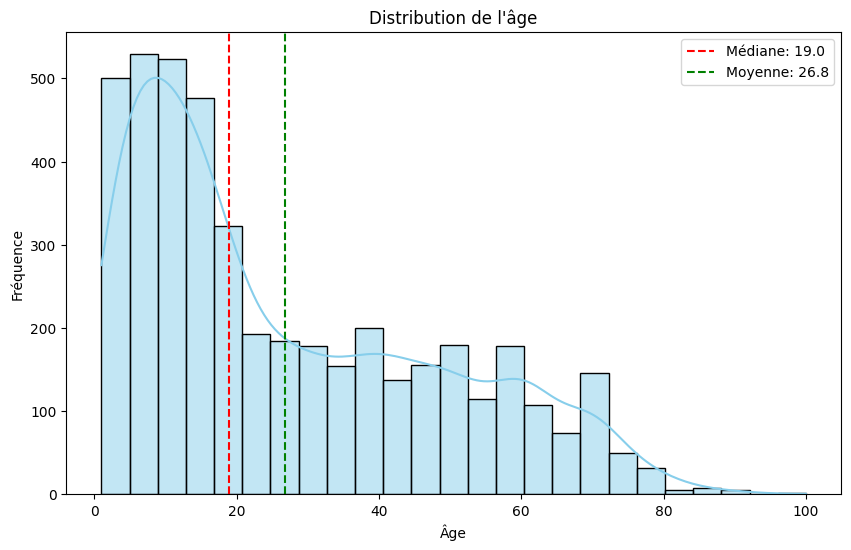

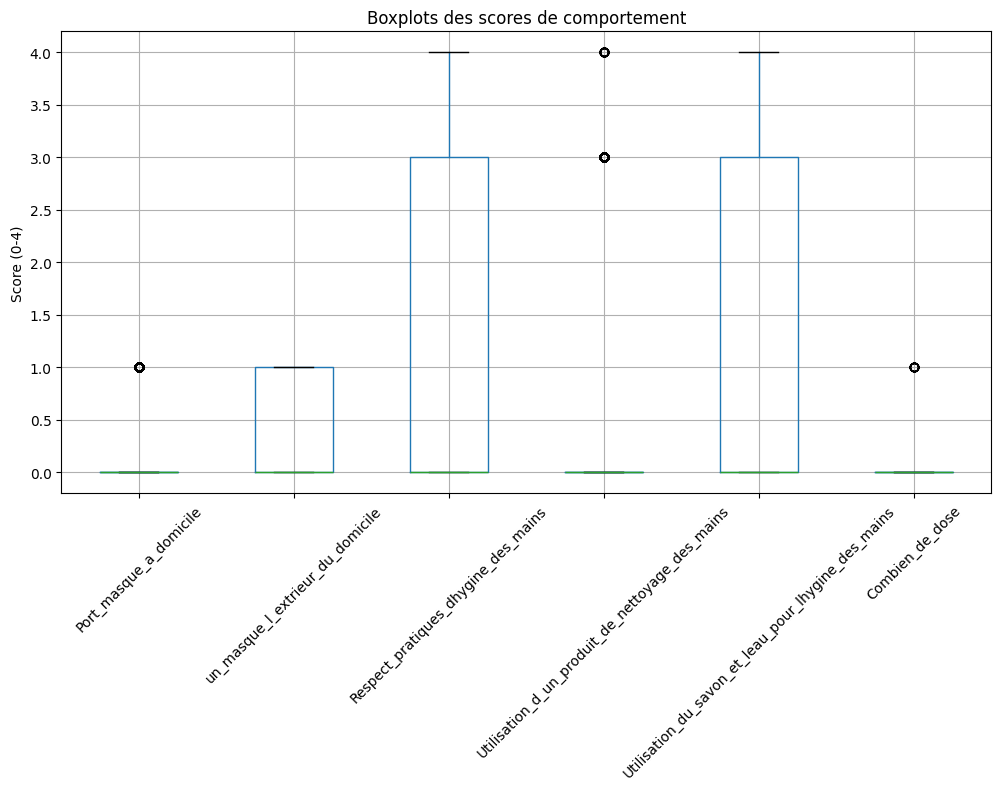

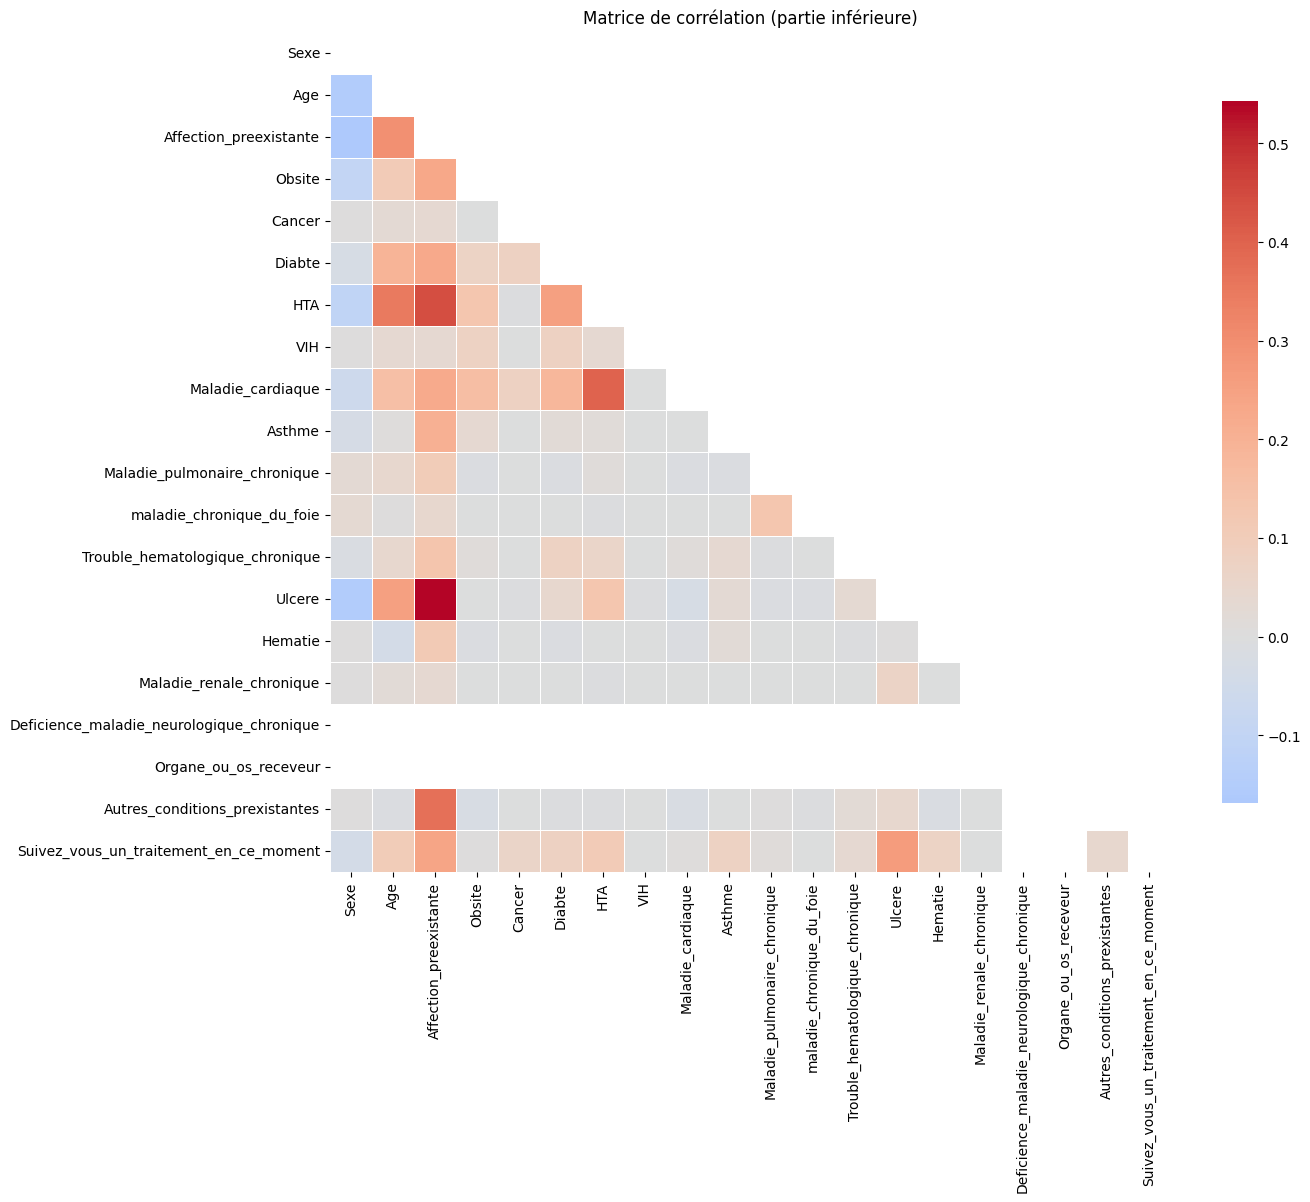

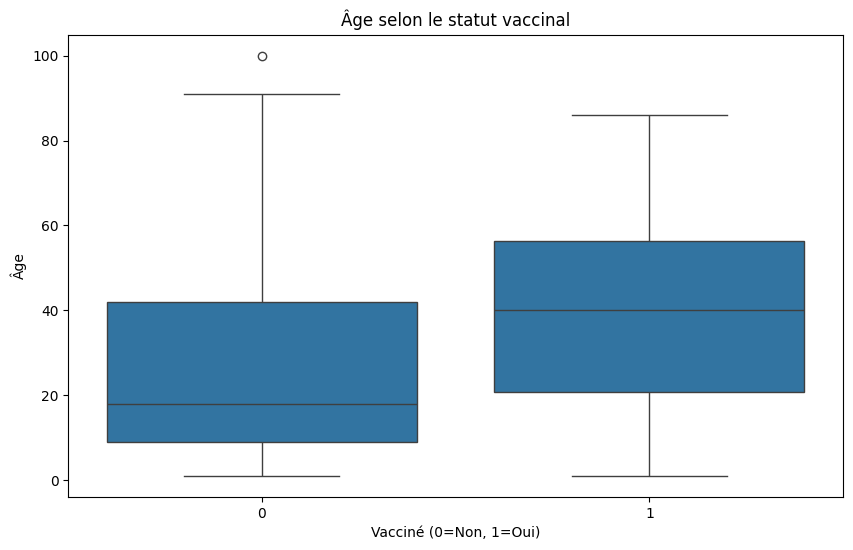

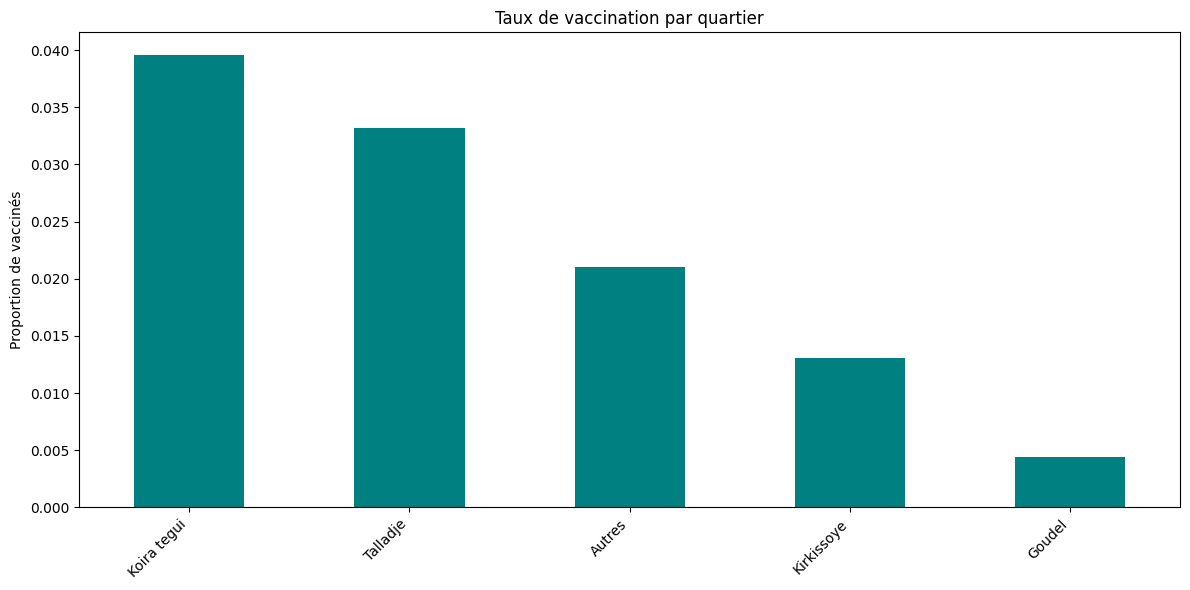


Âge moyen par sexe :
Sexe
0    29.504535
1    22.765227
Name: Age, dtype: float64


In [10]:
# ===============================
# 3. Analyse exploratoire avancée
# ===============================

# 3.1 Statistiques descriptives pour toutes les variables numériques
print("Statistiques descriptives des variables numériques :")
print(df_clean[num_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T)

# 3.2 Pour les variables catégorielles (avant encodage), on peut regarder les fréquences
# Mais ici nous avons déjà encodé, donc on peut utiliser les colonnes binaires pour voir les proportions.
# Sélection des colonnes binaires (0/1) pour avoir les fréquences
binary_cols_present = [col for col in binary_cols if col in df_clean.columns]
if binary_cols_present:
    print("\nProportions pour les variables binaires :")
    print(df_clean[binary_cols_present].mean().sort_values(ascending=False).to_frame(name='Proportion de "oui"'))

# 3.3 Distribution de l'âge (histogramme avec densité)
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Age'], bins=25, kde=True, color='skyblue')
plt.axvline(df_clean['Age'].median(), color='red', linestyle='--', label=f'Médiane: {df_clean["Age"].median():.1f}')
plt.axvline(df_clean['Age'].mean(), color='green', linestyle='--', label=f'Moyenne: {df_clean["Age"].mean():.1f}')
plt.title('Distribution de l\'âge')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.legend()
plt.show()

# 3.4 Boxplots des variables ordinales (comportements) pour visualiser la dispersion
ordinal_cols = [c for c in freq_cols if c in df_clean.columns]

if ordinal_cols:
    plt.figure(figsize=(12, 6))
    df_clean[ordinal_cols].boxplot()
    plt.title('Boxplots des scores de comportement')
    plt.ylabel('Score (0-4)')
    plt.xticks(rotation=45)
    plt.show()

# 3.5 Matrice de corrélation améliorée
plt.figure(figsize=(14, 12))
# On peut restreindre aux variables les plus pertinentes pour éviter le bruit
# Par exemple, on prend les 20 premières colonnes numériques (à adapter)
corr_cols = num_cols[:20]  # ou une sélection manuelle
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # masquer la partie supérieure
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False, center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation (partie inférieure)')
plt.tight_layout()
plt.show()

# 3.6 Analyse des relations bivariées (exemple : âge vs vaccination)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Vaccination', y='Age', data=df_clean)
plt.title('Âge selon le statut vaccinal')
plt.xlabel('Vacciné (0=Non, 1=Oui)')
plt.ylabel('Âge')
plt.show()

# 3.7 Pour les variables catégorielles, on peut faire des barplots des fréquences par quartier, profession, etc.
# Mais attention, on a fait du one-hot, donc il faut utiliser les colonnes d'origine avant encodage ou les indicateurs.
# Ici, on peut regarder les proportions de vaccination par quartier en utilisant les colonnes one-hot.
quartier_cols = [col for col in df_clean.columns if col.startswith('Quartier_')]
if quartier_cols:
    # On calcule le taux de vaccination moyen par quartier
    vacc_par_quartier = {}
    for q in quartier_cols:
        mask = df_clean[q] == 1
        if mask.sum() > 0:
            vacc_par_quartier[q.replace('Quartier_', '')] = df_clean.loc[mask, 'Vaccination'].mean()
    # Tri et affichage
    vacc_series = pd.Series(vacc_par_quartier).sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    vacc_series.plot(kind='bar', color='teal')
    plt.title('Taux de vaccination par quartier')
    plt.ylabel('Proportion de vaccinés')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# 3.8 Analyse des symptômes : on peut créer un score total de symptômes
symptom_cols = ['Fievre', 'Maux_de_gorge', 'Toux', 'Nez_qui_coule', 'Dyspne', 'Sueurs',
                'Frissons', 'Vomissements', 'Nausees', 'Diarrhee', 'Douleurs_abdominales',
                'Maux_de_tete', 'Eruption_cutane', 'Conjonctivite', 'Douleurs_musculaires',
                'Douleurs_articulaires', 'Perte_dapptit', 'Saignement_de_nez', 'Asthnie',
                'Malaise_general', 'Convulsions', 'Perte_de_connaissance', 'Perte_du_gout',
                'Perte_de_lodorat']
symptom_cols = [col for col in symptom_cols if col in df_clean.columns]
"""if symptom_cols:
    df_clean['Score_symptomes'] = df_clean[symptom_cols].sum(axis=1)
    plt.figure(figsize=(10, 6))
    sns.histplot(int(df_clean['Score_symptomes']),
                 bins=range(0, df_clean['Score_symptomes'].max()+2),
                 discrete=True)
    plt.title('Distribution du nombre de symptômes déclarés')
    plt.xlabel('Nombre de symptômes')
    plt.ylabel('Fréquence')
    plt.show()
"""
# 3.9 Analyse par sexe : par exemple, âge moyen par sexe
print("\nÂge moyen par sexe :")
print(df_clean[num_cols].groupby('Sexe')['Age'].mean())

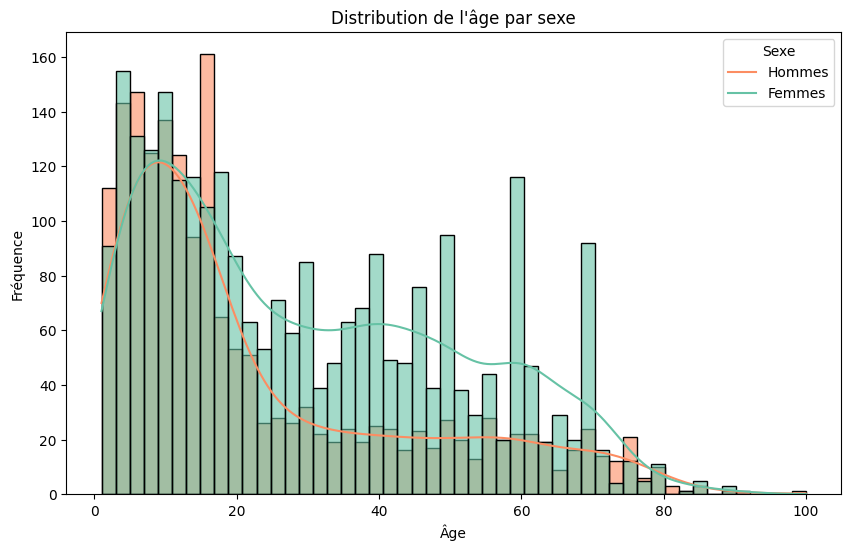

In [11]:

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Sexe', bins=50, kde=True, palette='Set2', alpha=0.6, edgecolor='black')
plt.title("Distribution de l'âge par sexe")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.legend(title="Sexe", labels=["Hommes", "Femmes"])
plt.show()




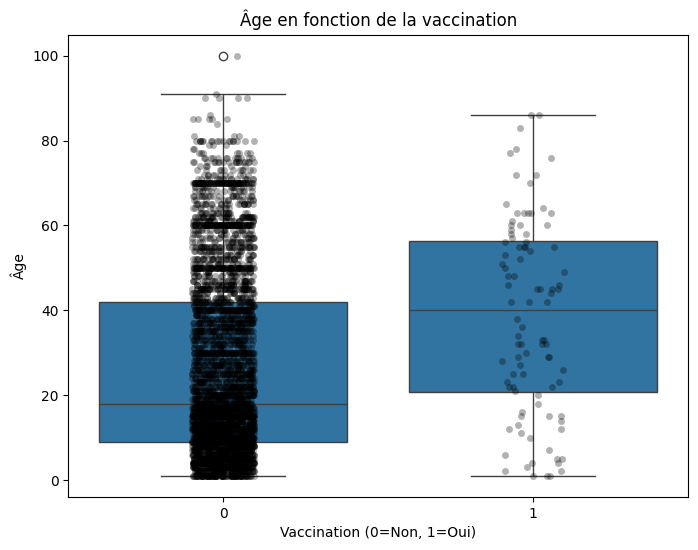

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Vaccination', y='Age', data=df_clean)
# optionnel : ajouter les points individuels pour voir la dispersion
sns.stripplot(x='Vaccination', y='Age', data=df_clean,
              color='black', alpha=0.3, jitter=True)
plt.title("Âge en fonction de la vaccination")
plt.xlabel("Vaccination (0=Non, 1=Oui)")
plt.ylabel("Âge")
plt.show()

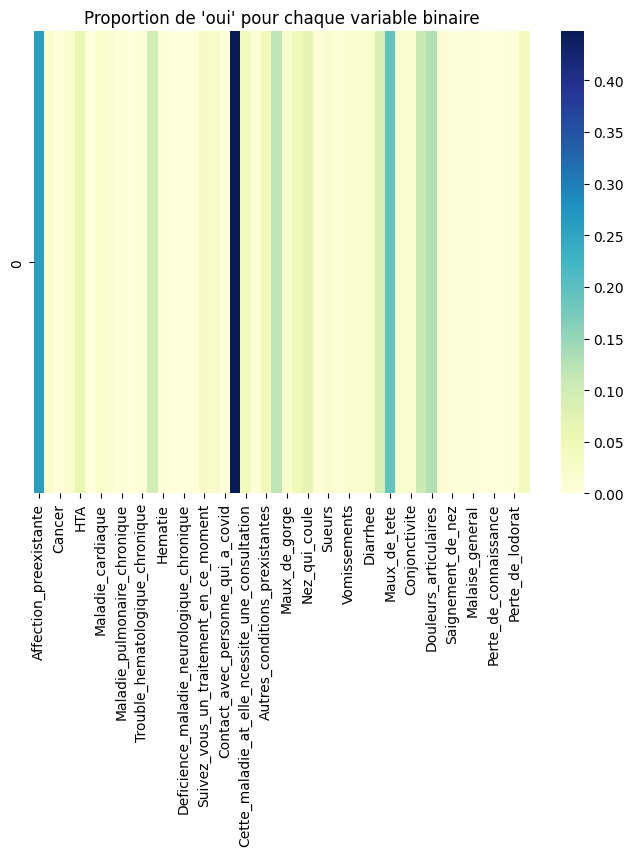

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[binary_cols_present].mean().to_frame().T, 
            cmap="YlGnBu", annot=False, fmt=".2f")
plt.title("Proportion de 'oui' pour chaque variable binaire")
plt.show()


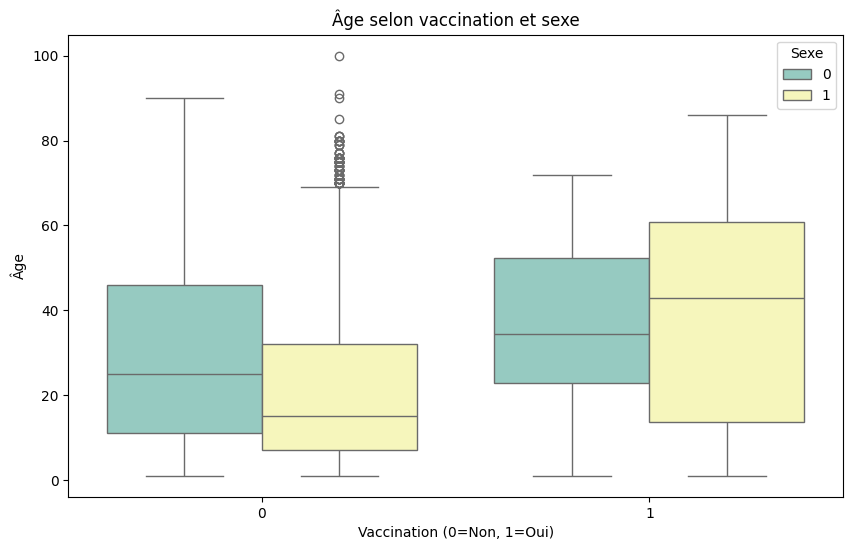

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Vaccination', y='Age', hue='Sexe', data=df_clean, palette='Set3')
plt.title("Âge selon vaccination et sexe")
plt.xlabel("Vaccination (0=Non, 1=Oui)")
plt.ylabel("Âge")
plt.show()
    

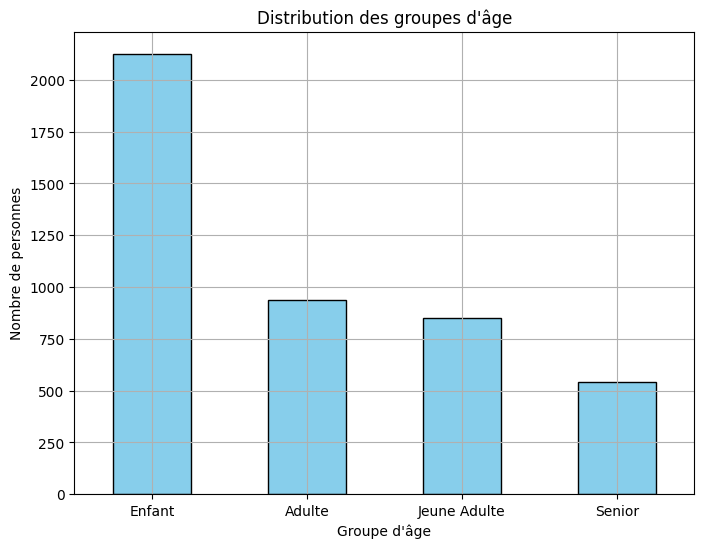

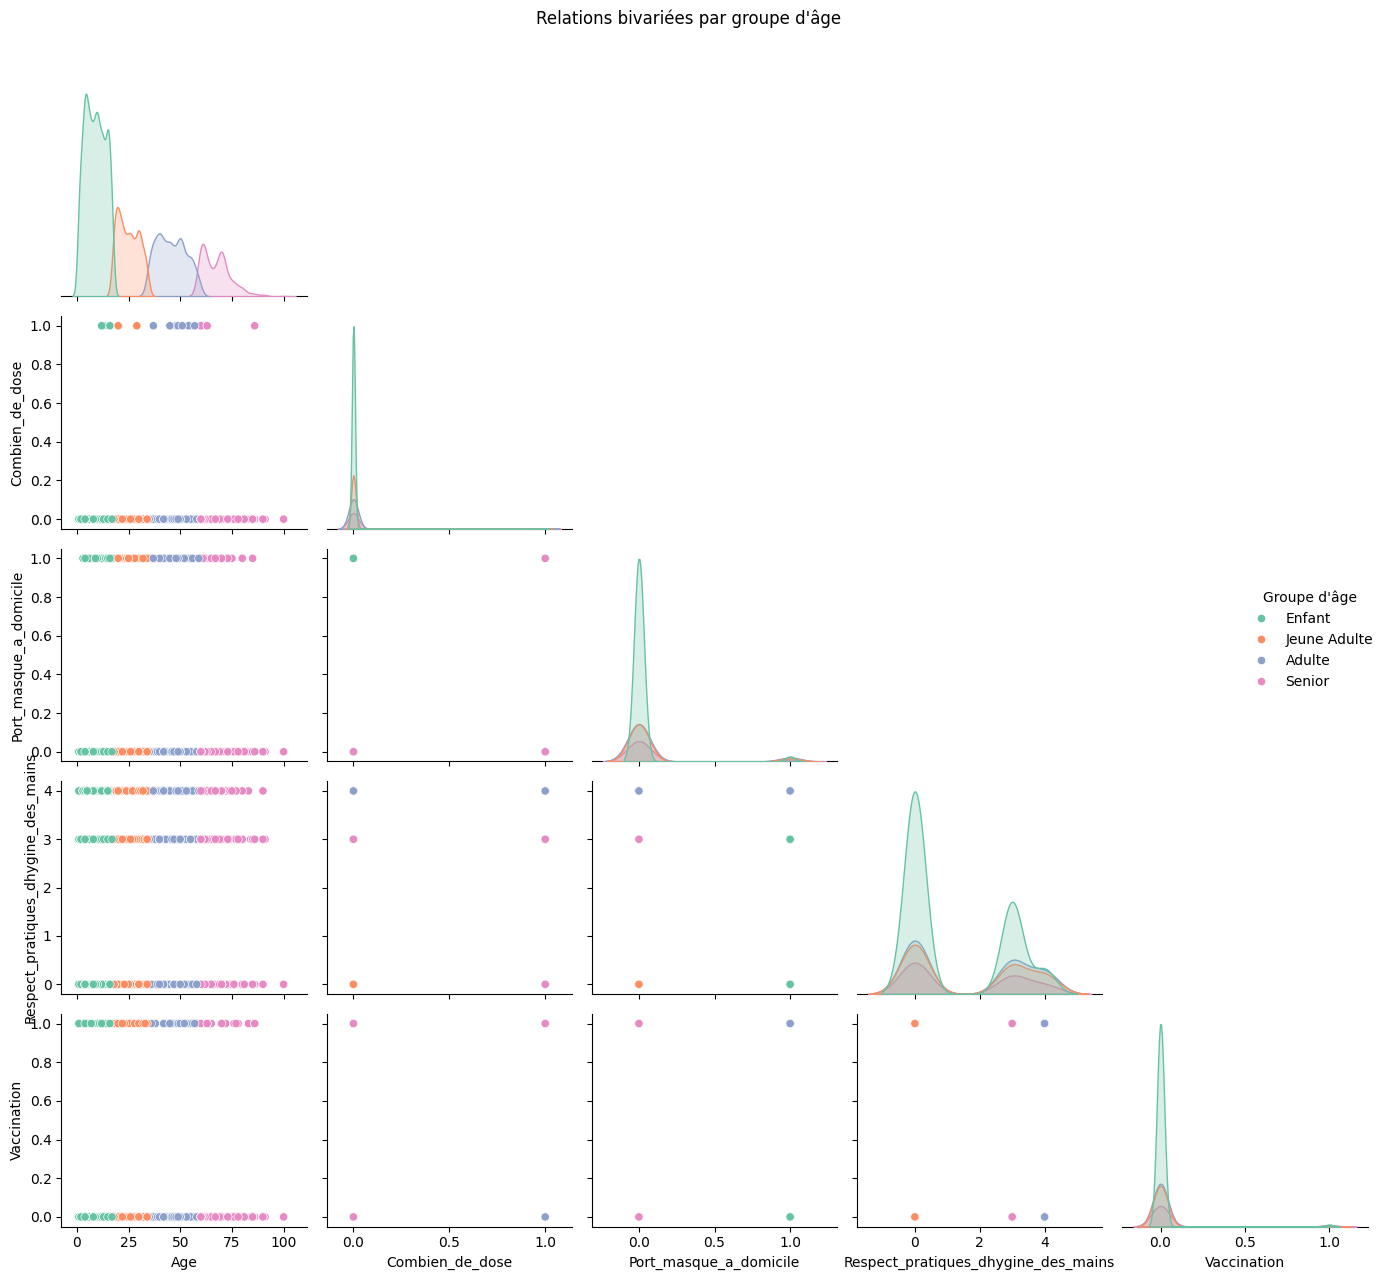

In [15]:
# Création des groupes d'âge
bins = [0, 18, 35, 60, np.inf]
labels = ['Enfant', 'Jeune Adulte', 'Adulte', 'Senior']
df_clean['Groupe d\'âge'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, right=False, include_lowest=True, ordered=True)

# Distribution des groupes d'âge
df_clean['Groupe d\'âge'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black', figsize=(8,6),
                                        title="Distribution des groupes d'âge", xlabel="Groupe d'âge",
                                        ylabel="Nombre de personnes", grid=True, rot=0)
plt.show()

cols_for_pairplot = ['Age', 'Combien_de_dose', 'Port_masque_a_domicile', 
                     'Respect_pratiques_dhygine_des_mains', 'Vaccination']  # exemple

# Vérifier que ces colonnes existent
existing_cols = [col for col in cols_for_pairplot if col in df.columns]
if len(existing_cols) < 2:
    print("Pas assez de colonnes pour le pairplot. Vérifiez les noms.")
else:
    # Pairplot avec hue basé sur le groupe d'âge
    sns.pairplot(data=df_clean, vars=existing_cols, hue='Groupe d\'âge', 
                 diag_kind='kde', palette='Set2', corner=True)
    plt.suptitle("Relations bivariées par groupe d'âge", y=1.02)
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


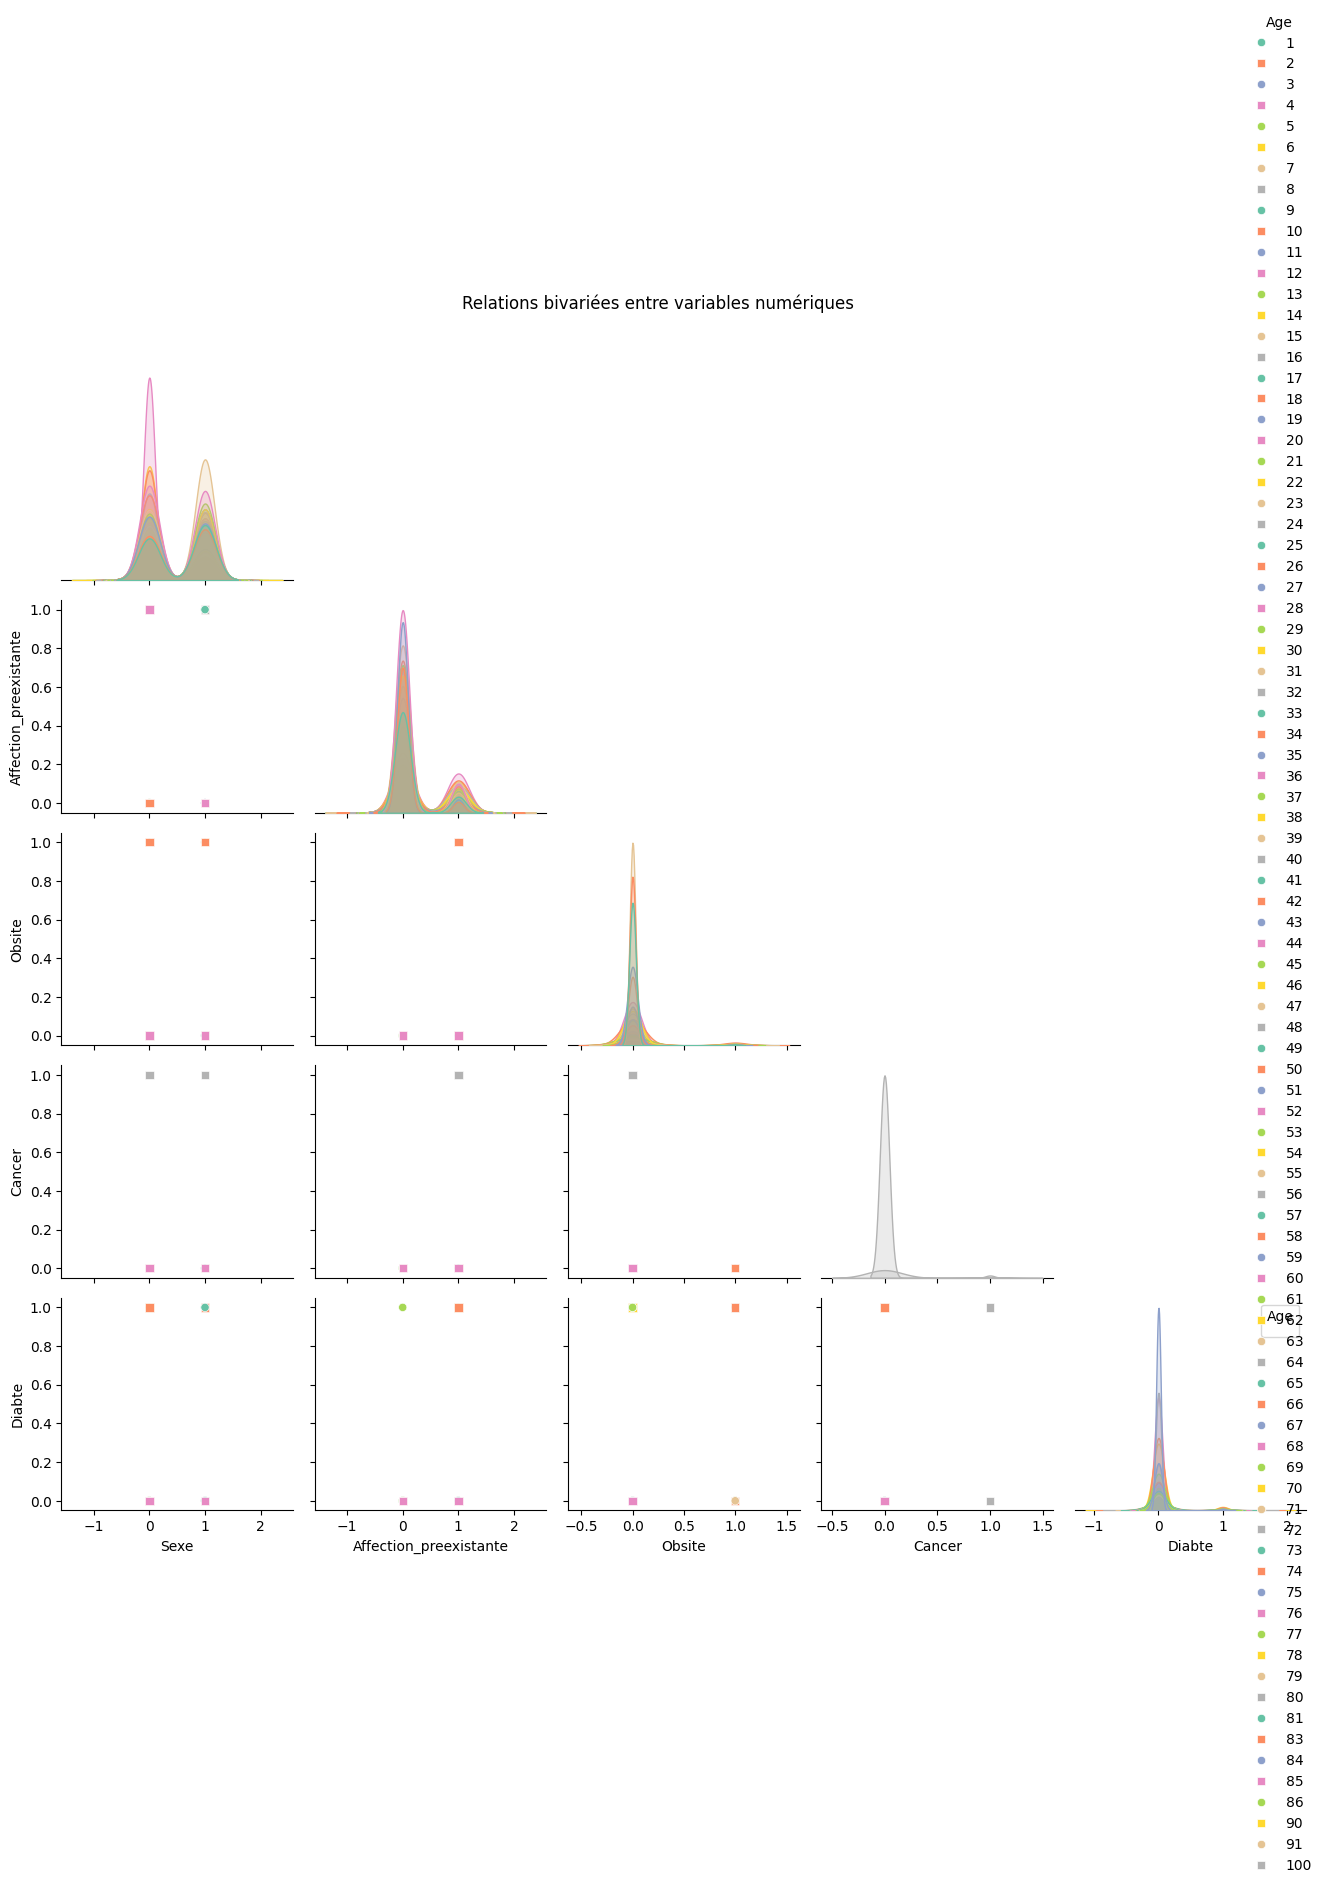

In [16]:

sns.pairplot(df_clean[num_cols[:6]], diag_kind='kde', corner=True,palette='Set2',hue='Age', markers=["o", "s"],diag_kws={'shade': True})
plt.suptitle("Relations bivariées entre variables numériques", y=1.02)
plt.tight_layout()
plt.legend(title="Age", loc='upper right')

plt.show()



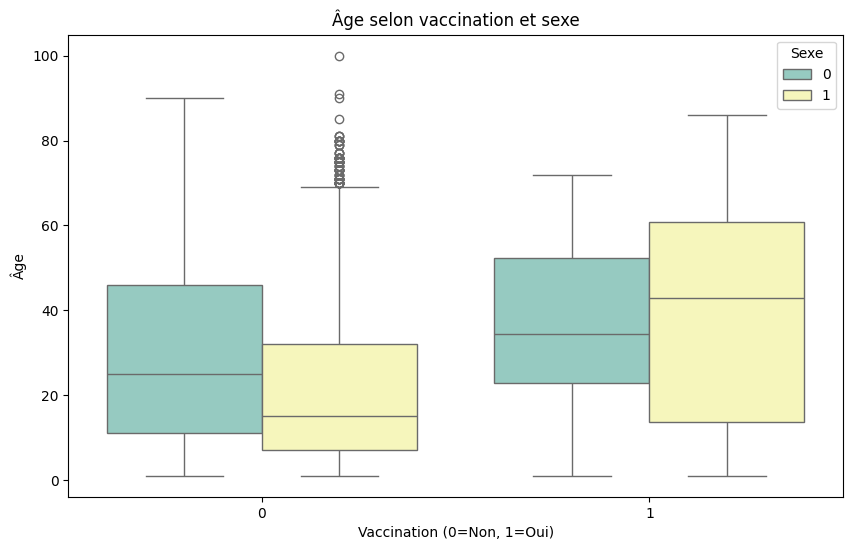

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Vaccination', y='Age', hue='Sexe', data=df_clean, palette='Set3')
plt.title("Âge selon vaccination et sexe")
plt.xlabel("Vaccination (0=Non, 1=Oui)")
plt.ylabel("Âge")
plt.show()


In [18]:
"""plt.figure(figsize=(8,6))
sns.barplot(x='Vaccination', y='Score_symptomes', data=df_clean, palette='Set2', ci=95)
plt.title("Score moyen de symptômes selon le statut vaccinal")
plt.xlabel("Vaccination (0=Non, 1=Oui)")
plt.ylabel("Score moyen de symptômes")
plt.show"""


'plt.figure(figsize=(8,6))\nsns.barplot(x=\'Vaccination\', y=\'Score_symptomes\', data=df_clean, palette=\'Set2\', ci=95)\nplt.title("Score moyen de symptômes selon le statut vaccinal")\nplt.xlabel("Vaccination (0=Non, 1=Oui)")\nplt.ylabel("Score moyen de symptômes")\nplt.show'

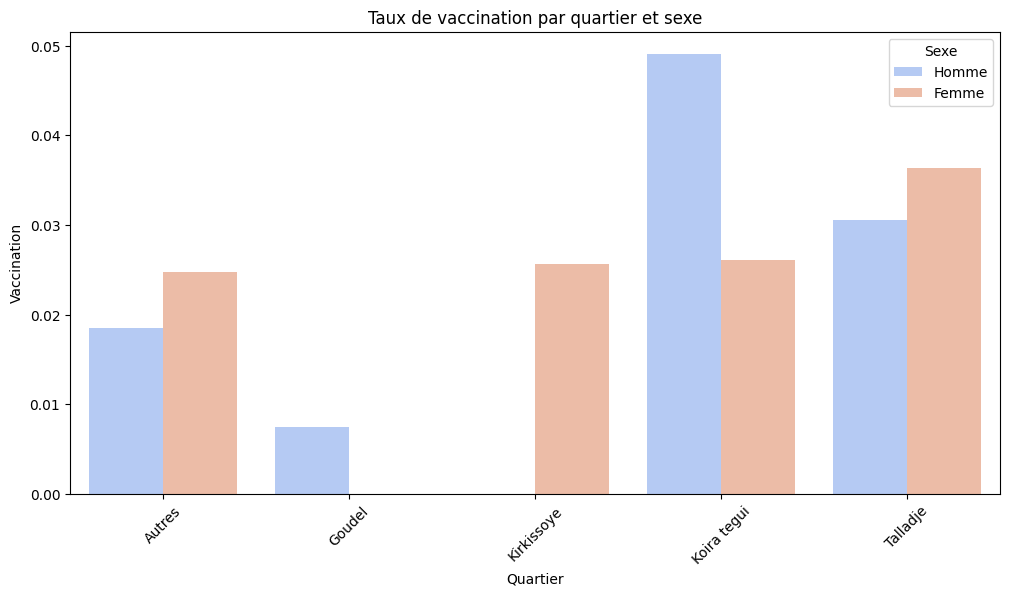

In [19]:
quartier_cols = [col for col in df_clean.columns if col.startswith('Quartier_')]
if quartier_cols:
    data_list = []
    for q in quartier_cols:
        quartier_name = q.replace('Quartier_', '')
        mask = df_clean[q] == 1
        if mask.sum() > 0:
            for sexe_val in df_clean['Sexe'].unique():
                taux = df_clean.loc[mask & (df_clean['Sexe']==sexe_val), 'Vaccination'].mean()
                data_list.append({'Quartier': quartier_name,
                                  'Sexe': 'Homme' if sexe_val==0 else 'Femme',
                                  'Vaccination': taux})
    df_quartier = pd.DataFrame(data_list)
    plt.figure(figsize=(12,6))
    sns.barplot(x='Quartier', y='Vaccination', hue='Sexe', data=df_quartier, palette='coolwarm')
    plt.title("Taux de vaccination par quartier et sexe")
    plt.xticks(rotation=45)
    plt.show()


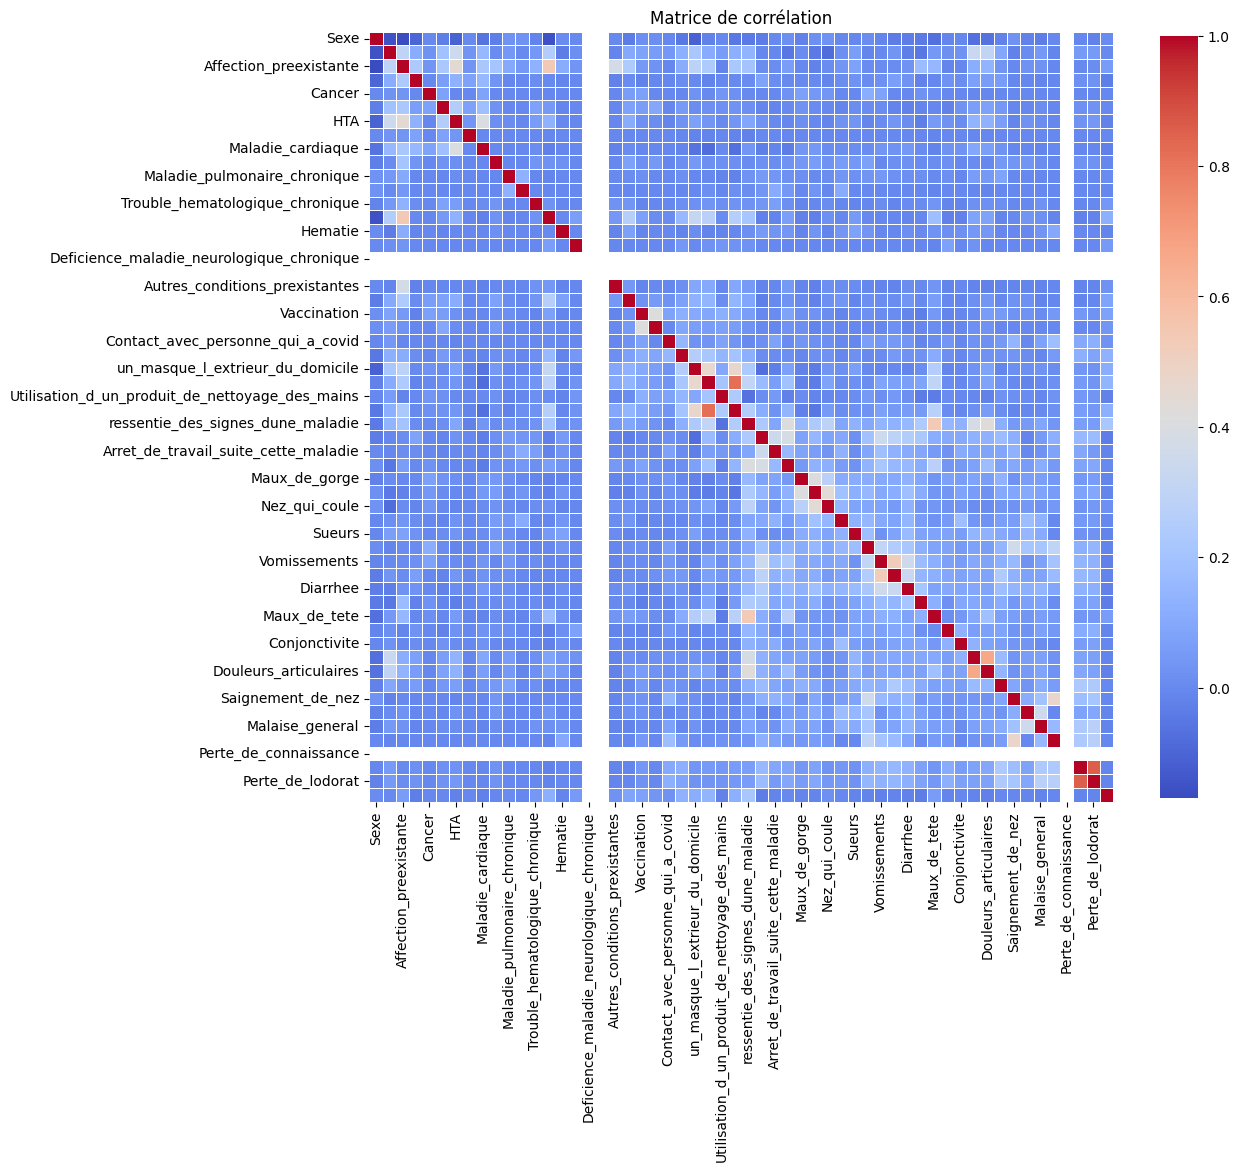

In [20]:
# Corrélations
plt.figure(figsize=(12, 10))
corr = df_clean[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.99})
plt.title('Matrice de corrélation')
plt.show()

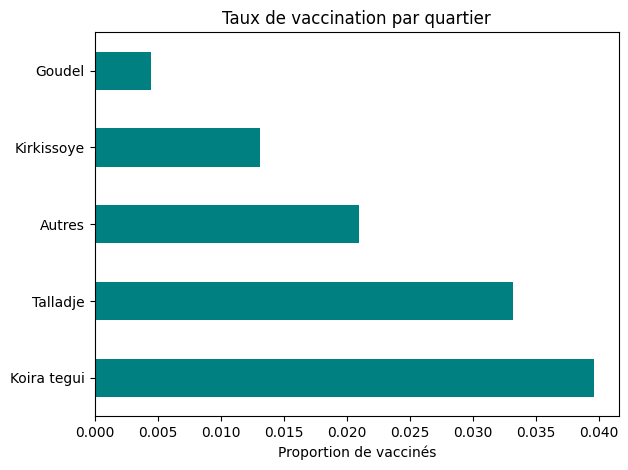

In [21]:
vacc_series.plot(kind='barh', color='teal')
plt.title('Taux de vaccination par quartier')
plt.xlabel('Proportion de vaccinés')
plt.tight_layout()
plt.show()


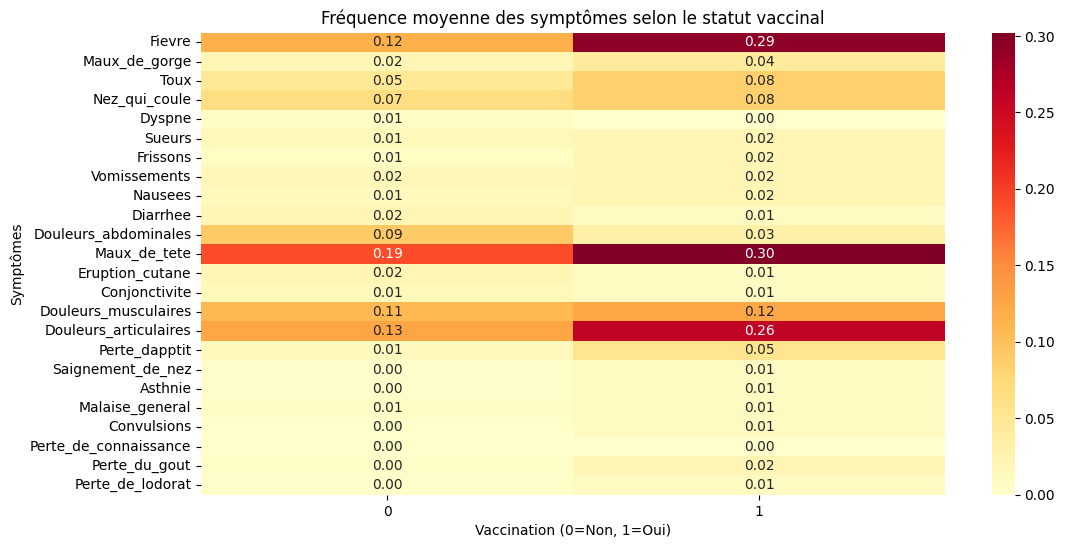

In [22]:
symptom_means = df_clean.groupby('Vaccination')[symptom_cols].mean().T
plt.figure(figsize=(12,6))
sns.heatmap(symptom_means, cmap="YlOrRd", annot=True, fmt=".2f")
plt.title("Fréquence moyenne des symptômes selon le statut vaccinal")
plt.xlabel("Vaccination (0=Non, 1=Oui)")
plt.ylabel("Symptômes")
plt.show()


### 4. Clustering (K-Means)

## clustring : k means


Nous standardisons les variables numériques pour qu'elles aient toutes la même échelle, indispensable pour les méthodes de clustering basées sur les distances comme K-Means.

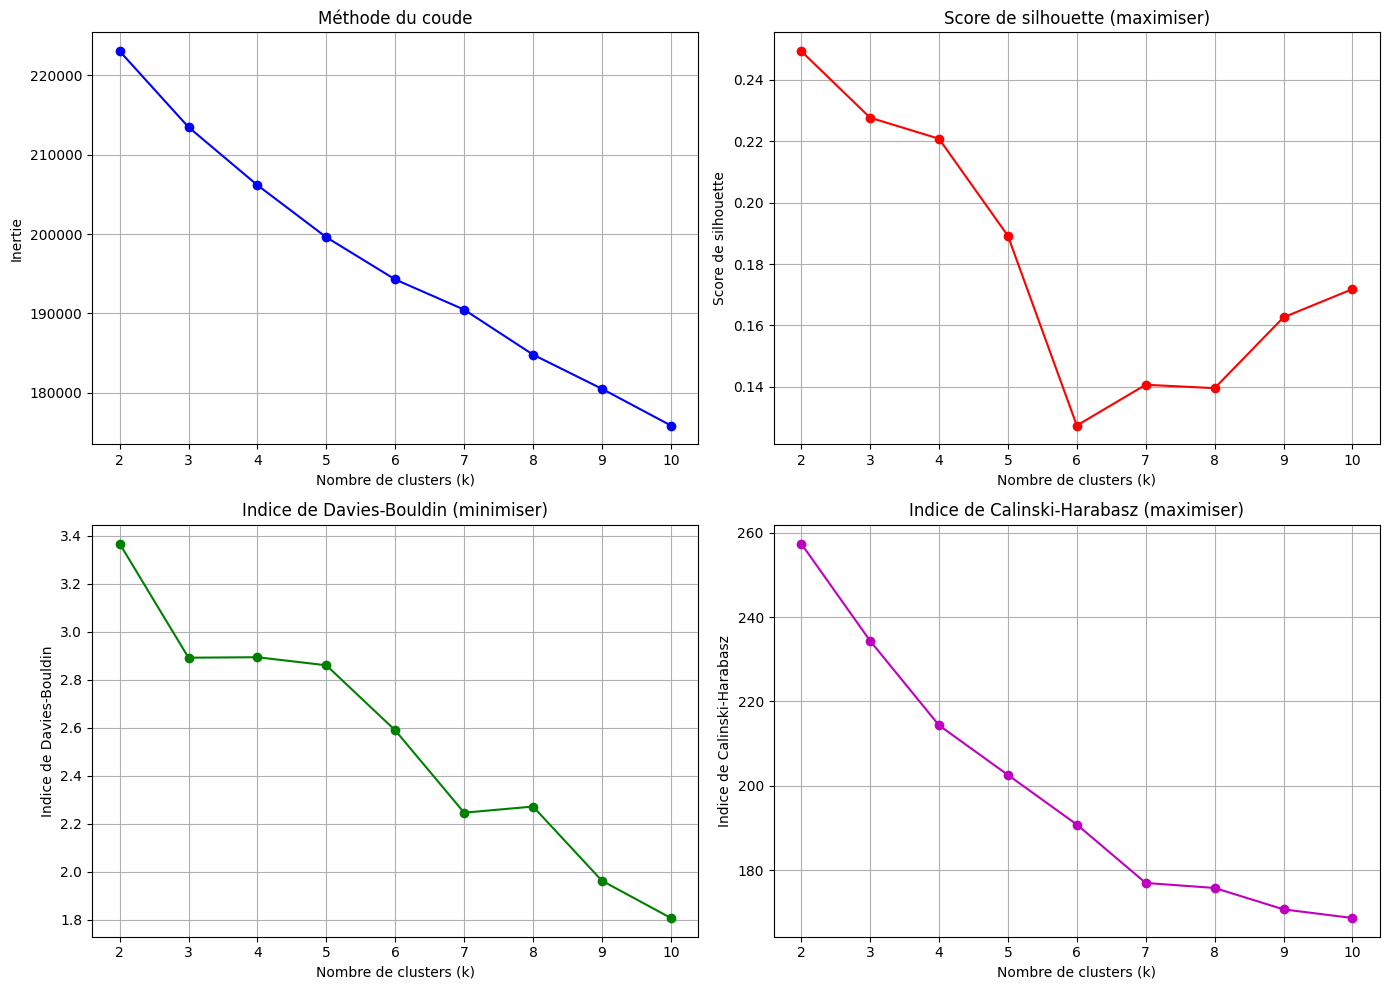

In [23]:
K_range = [i for i in range(2, 11)]
inertia = []
silhouette = []
davies_bouldin = []
calinski_harabasz = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(df_scaled, labels))
    davies_bouldin.append(davies_bouldin_score(df_scaled, labels))
    calinski_harabasz.append(calinski_harabasz_score(df_scaled, labels))

# Affichage des courbes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(K_range, inertia, 'bo-')
axes[0,0].set_xlabel('Nombre de clusters (k)')
axes[0,0].set_ylabel('Inertie')
axes[0,0].set_title('Méthode du coude')
axes[0,0].grid(True)

axes[0,1].plot(K_range, silhouette, 'ro-')
axes[0,1].set_xlabel('Nombre de clusters (k)')
axes[0,1].set_ylabel('Score de silhouette')
axes[0,1].set_title('Score de silhouette (maximiser)')
axes[0,1].grid(True)

axes[1,0].plot(K_range, davies_bouldin, 'go-')
axes[1,0].set_xlabel('Nombre de clusters (k)')
axes[1,0].set_ylabel('Indice de Davies-Bouldin')
axes[1,0].set_title('Indice de Davies-Bouldin (minimiser)')
axes[1,0].grid(True)

axes[1,1].plot(K_range, calinski_harabasz, 'mo-')
axes[1,1].set_xlabel('Nombre de clusters (k)')
axes[1,1].set_ylabel('Indice de Calinski-Harabasz')
axes[1,1].set_title('Indice de Calinski-Harabasz (maximiser)')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Affichage des valeurs numériques
results = pd.DataFrame({
    'k': list(K_range),
    'Inertie': inertia,
    'Silhouette': silhouette,
    'Davies-Bouldin': davies_bouldin,
    'Calinski-Harabasz': calinski_harabasz
})


In [24]:
print(results)

    k        Inertie  Silhouette  Davies-Bouldin  Calinski-Harabasz
0   2  223052.611874    0.249317        3.367261         257.428401
1   3  213465.453388    0.227635        2.891799         234.372545
2   4  206155.058249    0.220783        2.893764         214.328427
3   5  199591.357704    0.189199        2.860242         202.555820
4   6  194272.376060    0.127435        2.589218         190.789237
5   7  190467.648225    0.140700        2.246281         176.929193
6   8  184799.241365    0.139583        2.271805         175.743328
7   9  180491.588431    0.162645        1.962670         170.664727
8  10  175871.362019    0.171826        1.807550         168.618168


In [25]:
results

,k,Inertie,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,223052.611874,0.249317,3.367261,257.428401
1,3,213465.453388,0.227635,2.891799,234.372545
2,4,206155.058249,0.220783,2.893764,214.328427
3,5,199591.357704,0.189199,2.860242,202.555820
4,6,194272.376060,0.127435,2.589218,190.789237
5,7,190467.648225,0.140700,2.246281,176.929193
6,8,184799.241365,0.139583,2.271805,175.743328
7,9,180491.588431,0.162645,1.962670,170.664727
8,10,175871.362019,0.171826,1.807550,168.618168


https://www.youtube.com/watch?v=kPzWTSpYjo4

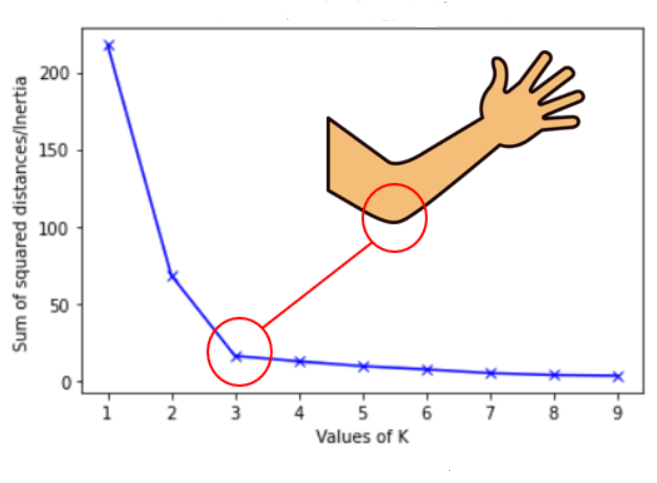
https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.researchgate.net%2Ffigure%2FApplication-de-la-methode-du-coude-sur-lalgorithme-K-prototype-Ban21_fig18_359279482&psig=AOvVaw3u2WP0P5ol9sa9AEr5K5-G&ust=1772416246553000&source=images&cd=vfe&opi=89978449&ved=0CBUQjRxqFwoTCLCf05vL_ZIDFQAAAAAdAAAAABAE


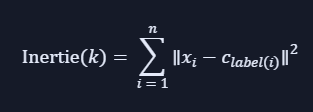

Formule de l’inertie
L’inertie mesure la somme des distances au carré entre chaque point et le centre de son cluster :


presentations des formules des métriques d’évaluation du clustering (inertie, silhouette, Davies-Bouldin, Calinski-Harabasz) et explication de leur interprétation pour choisir le nombre optimal de clusters.

########## 

4.3 Visualisation des métriques de clustering pour le k choisi


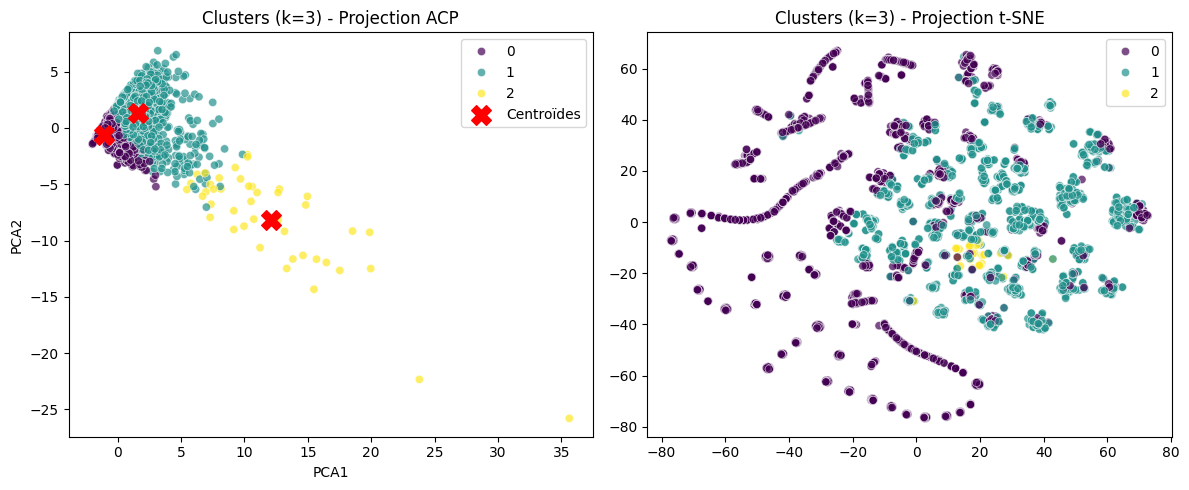

In [26]:
k_optimal = 3  # à ajuster
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)
df_clean['Cluster'] = clusters

# Réduction dimensionnelle pour visualisation
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)
df_clean['PCA1'] = pca_result[:, 0]
df_clean['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_clean, palette='viridis', alpha=0.7)
plt.title(f'Clusters (k={k_optimal}) - Projection ACP')

# On peut aussi ajouter les centroïdes dans l'espace ACP
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c='red', marker='X', s=200, label='Centroïdes')
plt.legend()

plt.subplot(1,2,2)
# Utilisation de t-SNE pour une autre visualisation (parfois plus lisible)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(df_scaled)
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=clusters, palette='viridis', alpha=0.7)
plt.title(f'Clusters (k={k_optimal}) - Projection t-SNE')
plt.tight_layout()
plt.show()

description : 
La projection ACP et t-SNE permettent de visualiser la séparation des clusters dans un espace 2D. Les centroïdes en ACP montrent les centres des groupes. t-SNE, bien que non linéaire, peut révéler des structures plus complexes.

4.4 Analyse détaillée des profils de clusters

Nous allons calculer les moyennes par cluster pour chaque variable, et également regarder les distributions de quelques variables clés.

In [27]:
# Profils moyens
cluster_means = df_clean.groupby('Cluster')[num_cols].mean().T
print("Moyennes des variables par cluster :")
cluster_means

Moyennes des variables par cluster :


Cluster,0,1,2
Sexe,0.452710,0.324716,0.302326
Age,22.422954,34.358134,32.348837
Affection_preexistante,0.096706,0.545397,0.348837
Obsite,0.011690,0.030265,0.046512
Cancer,0.000000,0.000631,0.023256
Diabte,0.008147,0.035939,0.046512
HTA,0.024796,0.137453,0.139535
VIH,0.000708,0.000000,0.000000
Maladie_cardiaque,0.010627,0.029004,0.046512
Asthme,0.007085,0.029004,0.093023


In [28]:


# Normalisation pour visualisation en heatmap
scaler_mm = MinMaxScaler()
cluster_means_scaled = scaler_mm.fit_transform(cluster_means.T).T
cluster_means_scaled = pd.DataFrame(cluster_means_scaled, index=cluster_means.index, columns=cluster_means.columns)

plt.figure(figsize=(14,8))
sns.heatmap(cluster_means_scaled, annot=True, cmap='coolwarm', center=0.5, fmt='.2f')
plt.title('Profils normalisés des clusters')
plt.ylabel('Variables')
plt.xlabel('Cluster')
plt.show()

# Boxplots pour quelques variables
fig, axes = plt.subplots(2, 3, figsize=(15,10))
selected_vars = ['Age', 'Combien_de_dose'] + [c for c in freq_cols if c in df_clean.columns][:4]
for i, var in enumerate(selected_vars):
    if var in df_clean.columns:
        ax = axes[i//3, i%3]
        sns.boxplot(x='Cluster', y=var, data=df_clean, ax=ax)
        ax.set_title(f'Distribution de {var} par cluster')
plt.tight_layout()
plt.show()

NameError: name 'MinMaxScaler' is not defined

description :
 La heatmap des moyennes par cluster (normalisées) permet de visualiser rapidement les tendances : plus une cellule est rouge, plus la valeur est élevée pour ce cluster. Les boxplots montrent la dispersion de certaines variables au sein de chaque groupe.

4.5 Interprétation et étiquetage des clusters

In [ ]:
# Affichage des caractéristiques dominantes
for cluster in sorted(df_clean['Cluster'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(f"Taille : {(df_clean['Cluster']==cluster).sum()} individus")
    # Variables avec les moyennes les plus élevées par rapport aux autres clusters
    profile = cluster_means[cluster].sort_values(ascending=False)
    print("Top 5 variables avec les moyennes les plus élevées :")
    print(profile.head(5))
    # On peut aussi regarder les variables binaires avec des proportions élevées


--- Cluster 0 ---
Taille : 2823 individus
Top 5 variables avec les moyennes les plus élevées :
Age                                                    22.422954
Utilisation_du_savon_et_leau_pour_lhygine_des_mains     0.740347
Respect_pratiques_dhygine_des_mains                     0.690046
Sexe                                                    0.452710
un_masque_l_extrieur_du_domicile                        0.232023
Name: 0, dtype: float64

--- Cluster 1 ---
Taille : 1586 individus
Top 5 variables avec les moyennes les plus élevées :
Age                                                    34.358134
Respect_pratiques_dhygine_des_mains                     2.695460
Utilisation_du_savon_et_leau_pour_lhygine_des_mains     2.559899
ressentie_des_signes_dune_maladie                       0.862547
un_masque_l_extrieur_du_domicile                        0.733291
Name: 1, dtype: float64

--- Cluster 2 ---
Taille : 43 individus
Top 5 variables avec les moyennes les plus élevées :
Age             

desc : Cluster 0 : personnes âgées (âge moyen élevé), avec antécédents, vaccinées, bon respect des gestes barrières → « Seniors protégés ».

Cluster 1 : jeunes adultes, peu d'antécédents, faible vaccination, comportements à risque → « Jeunes exposés ».

Cluster 2 : population d'âge moyen, antécédents modérés, comportements variables → « Groupe intermédiaire ».

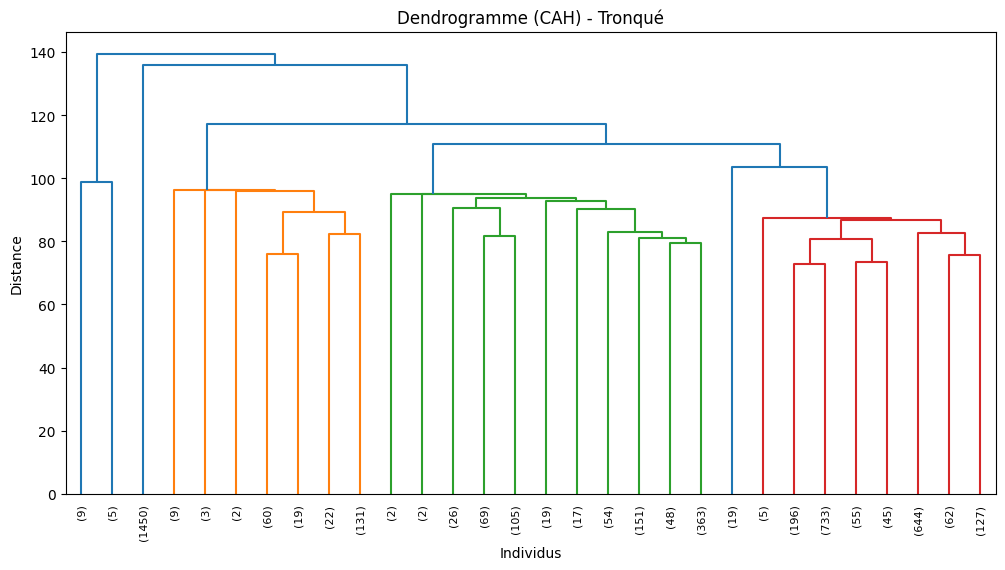

Adjusted Rand Index entre K-Means et CAH : 0.13483277950720238


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Classification hiérarchique
linked = linkage(df_scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogramme (CAH) - Tronqué')
plt.xlabel('Individus')
plt.ylabel('Distance')
plt.show()

# On peut couper l'arbre à k=3
clusters_hier = fcluster(linked, t=3, criterion='maxclust') - 1  # pour avoir 0,1,2
# Comparaison avec K-Means
from sklearn.metrics import adjusted_rand_score
print("Adjusted Rand Index entre K-Means et CAH :", adjusted_rand_score(clusters, clusters_hier))

Enfin, nous pouvons exporter les clusters avec leurs caractéristiques pour une analyse plus approfondie.

In [ ]:
# Ajouter les clusters au dataframe original (avec les noms des clusters)
cluster_names = {0: 'Seniors protégés', 1: 'Jeunes exposés', 2: 'Intermédiaire'}
df_clean['Cluster_label'] = df_clean['Cluster'].map(cluster_names)

# Sauvegarde
df_clean.to_csv('resultats_clustering.csv', index=False)
print("Résultats sauvegardés.")

Résultats sauvegardés.


 Nous avons maintenant une segmentation interprétable de la population en trois groupes distincts, avec des profils clairs. Ces résultats peuvent être utilisés pour orienter des actions de santé publique ciblées.